# Feeding America Map the Meal Gap 2026 — Minnesota County EDA

**2026 MinneMUDAC Student Data Challenge | Undergraduate Division**  
**Source:** `data/MMG2026_2024_Data_To_Share.xlsx`

## Step 1 — Imports and presentation settings

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 110)
pd.set_option('display.float_format', '{:,.3f}'.format)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.figsize': (11, 6), 'figure.dpi': 110})

print('Python:', sys.version.split()[0])
print('Pandas:', pd.__version__)
print('NumPy:', np.__version__)
print('Seaborn:', sns.__version__)

Python: 3.13.14
Pandas: 3.0.6
NumPy: 2.5.3
Seaborn: 0.13.2


## Step 2 — Workbook path, sheet names, and source version
The notebook is in the **project root**; the workbook lives directly inside `data/`. Inspect the `Read Me` worksheet separately; do not combine different geographic sheets.

In [2]:
mmg_path = 'data/MMG2026_2024_Data_To_Share.xlsx'
assert Path(mmg_path).is_file(), f'File not found: {Path(mmg_path).resolve()}'

with pd.ExcelFile(mmg_path, engine='openpyxl') as xls:
    print('Available worksheets:', xls.sheet_names)

source_notes = pd.read_excel(mmg_path, sheet_name='Read Me', header=None, engine='openpyxl')
display(source_notes.head(14))
print('Source: Feeding America, Map the Meal Gap 2026 (2024 data).')
print('Workbook Read Me last updated: July 28, 2026.')

Available worksheets: ['Read Me', 'County', 'Congressional District', 'State', 'Metro Area (50+ Only)', 'National (50+ Only)']


,0,1,2,3,4
0,Dataset that combines Feeding America's Map th...,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,Recommended Citation,NaN,NaN,NaN,NaN
3,"Ribar, D.C., Harris, V., Dewey, A., Dawes, S.,...",NaN,NaN,NaN,NaN
4,Version History,Note,NaN,NaN,NaN
5,MMG2026_2024_Data_To_Share,"This file was last updated on July 28, 2026.",NaN,NaN,NaN
6,General Notes,NaN,NaN,NaN,NaN
7,"All overall, child, race/ethnicty food insecur...",NaN,NaN,NaN,NaN
8,Blank cells indicate that values are currently...,NaN,NaN,NaN,NaN
9,Notes on Revised 2023 Estimates,NaN,NaN,NaN,NaN


Source: Feeding America, Map the Meal Gap 2026 (2024 data).
Workbook Read Me last updated: July 28, 2026.


## Step 3 — Read the `County` sheet and retain the original
`FIPS` is a geographic identifier and must be held as text, not analyzed as a number.

In [3]:
mmg_county_raw = pd.read_excel(
    mmg_path,
    sheet_name='County',
    dtype={'FIPS': 'string'},
    engine='openpyxl'
)
mmg_county = mmg_county_raw.copy()
print('National county records / columns:', mmg_county.shape)
display(mmg_county.head())

National county records / columns: (3144, 25)


,FIPS,State,"County, State",Year,Overall Food Insecurity Rate,# of Food Insecure Persons Overall,Food Insecurity Rate among Black Persons (all ethnicities),Food Insecurity Rate among Hispanic Persons (any race),"Food Insecurity Rate among White, non-Hispanic Persons",SNAP Threshold,% FI ≤ SNAP Threshold,% FI > SNAP Threshold,Child Food Insecurity Rate,# of Food Insecure Children,% food insecure children in HH w/ HH incomes below 185 FPL,% food insecure children in HH w/ HH incomes above 185 FPL,Imputed Market Basket Data,Cost Per Meal,Weighted weekly $ needed by FI,Weighted Annual Food Budget Shortfall,Rural-Urban Continuum Code (2013),Rural-Urban Continuum Code (2023),Census Region,Census Division,FNS Region
0,1001,AL,"Autauga County, Alabama",2024,0.156,"9,350.000",0.260,NaN,0.120,1.300,0.444,0.556,0.203,"2,850.000",0.670,0.330,NaN,3.680,23.020,"6,528,000.000",2.000,2,South,East South Central,Southeast
1,1003,AL,"Baldwin County, Alabama",2024,0.154,"37,940.000",0.300,0.180,0.110,1.300,0.455,0.545,0.196,"10,210.000",0.640,0.360,NaN,4.150,25.950,"29,861,000.000",3.000,3,South,East South Central,Southeast
2,1005,AL,"Barbour County, Alabama",2024,0.193,"4,750.000",0.330,0.250,0.140,1.300,0.419,0.581,0.308,"1,580.000",0.940,0.060,NaN,3.530,22.080,"3,181,000.000",6.000,6,South,East South Central,Southeast
3,1007,AL,"Bibb County, Alabama",2024,0.202,"4,470.000",0.470,NaN,0.150,1.300,0.600,0.400,0.279,"1,240.000",0.850,0.150,NaN,3.430,21.490,"2,914,000.000",1.000,1,South,East South Central,Southeast
4,1009,AL,"Blount County, Alabama",2024,0.184,"10,960.000",0.280,0.220,0.130,1.300,0.590,0.410,0.213,"2,930.000",0.710,0.290,NaN,3.440,21.560,"7,167,000.000",1.000,1,South,East South Central,Southeast


## Step 4 — Dataset schema and initial completeness
Look for deviations from the supplied 25-column county layout, apparent object/numeric fields, and unexpectedly empty columns.

In [4]:
schema = pd.DataFrame({
    'column': mmg_county.columns,
    'dtype': mmg_county.dtypes.astype(str).values,
    'non_null': mmg_county.notna().sum().values,
    'missing_pct': (mmg_county.isna().mean() * 100).round(1).values
})
display(schema)
print('Years in county sheet:')
display(mmg_county['Year'].value_counts(dropna=False).sort_index())
print('Overall county rows:', len(mmg_county))

,column,dtype,non_null,missing_pct
0,FIPS,string,3144,0.000
1,State,str,3144,0.000
2,"County, State",str,3144,0.000
3,Year,int64,3144,0.000
4,Overall Food Insecurity Rate,float64,3142,0.100
5,# of Food Insecure Persons Overall,float64,3142,0.100
6,Food Insecurity Rate among Black Persons (all ...,float64,1478,53.000
7,Food Insecurity Rate among Hispanic Persons (a...,float64,1860,40.800
8,"Food Insecurity Rate among White, non-Hispanic...",float64,3082,2.000
9,SNAP Threshold,float64,3144,0.000


Years in county sheet:


Year
2024    3144
Name: count, dtype: int64

Overall county rows: 3144


## Step 5 — Filter Minnesota; standardize FIPS and county names
**Expected:** 87 counties, 87 records, 2024 only. A missing county is an error to investigate rather than silently ignore.

In [5]:
mmg_mn = mmg_county.loc[
    mmg_county['State'].astype('string').str.strip().eq('MN')
].copy()

mmg_mn['FIPS'] = mmg_mn['FIPS'].astype('string').str.strip().str.zfill(5)
mmg_mn['Year'] = pd.to_numeric(mmg_mn['Year'], errors='coerce').astype('Int64')
mmg_mn['county_name'] = (
    mmg_mn['County, State']
    .astype('string')
    .str.replace(r',\s*Minnesota$', '', regex=True)
    .str.replace(r'\s+County$', '', regex=True)
)

print('MN records:', len(mmg_mn))
print('Distinct county FIPS:', mmg_mn['FIPS'].nunique())
print('Years:', mmg_mn['Year'].dropna().unique().tolist())
assert len(mmg_mn) == 87 and mmg_mn['FIPS'].nunique() == 87
assert mmg_mn['Year'].eq(2024).all()
assert mmg_mn['FIPS'].str.fullmatch(r'27\d{3}').all()
display(mmg_mn[['FIPS', 'county_name', 'Year']].head())

MN records: 87
Distinct county FIPS: 87
Years: [2024]


,FIPS,county_name,Year
1316,27001,Aitkin,2024
1317,27003,Anoka,2024
1318,27005,Becker,2024
1319,27007,Beltrami,2024
1320,27009,Benton,2024


## Step 6 — Rename 2024 source columns into standardized analytical names
The names align with the previous MMG2025 notebook so a **later** 2022–2024 county-year union will be straightforward. Do not use fixed Excel column positions; the two workbooks have different layouts.

In [6]:
column_map = {
    'Overall Food Insecurity Rate': 'fi_rate',
    '# of Food Insecure Persons Overall': 'fi_people',
    'Child Food Insecurity Rate': 'child_fi_rate',
    '# of Food Insecure Children': 'fi_children',
    'SNAP Threshold': 'snap_threshold',
    '% FI ≤ SNAP Threshold': 'fi_below_snap_share',
    '% FI > SNAP Threshold': 'fi_above_snap_share',
    '% food insecure children in HH w/ HH incomes below 185 FPL': 'child_fi_below_185fpl_share',
    '% food insecure children in HH w/ HH incomes above 185 FPL': 'child_fi_above_185fpl_share',
    'Cost Per Meal': 'cost_per_meal',
    'Weighted weekly $ needed by FI': 'weekly_gap_per_person',
    'Weighted Annual Food Budget Shortfall': 'annual_budget_shortfall',
    'Rural-Urban Continuum Code (2013)': 'rucc_2013',
    'Rural-Urban Continuum Code (2023)': 'rucc_2023',
    'Food Insecurity Rate among Black Persons (all ethnicities)': 'fi_rate_black',
    'Food Insecurity Rate among Hispanic Persons (any race)': 'fi_rate_hispanic',
    'Food Insecurity Rate among White, non-Hispanic Persons': 'fi_rate_white_non_hispanic',
    'Imputed Market Basket Data': 'market_basket_imputation_raw',
}
missing_headers = sorted(set(column_map).difference(mmg_mn.columns))
assert not missing_headers, f'Unexpected/missing columns: {missing_headers}'

mmg_mn = mmg_mn.rename(columns=column_map)

numeric_cols = [name for name in column_map.values()
                if name != 'market_basket_imputation_raw']
for col in numeric_cols:
    mmg_mn[col] = pd.to_numeric(mmg_mn[col], errors='coerce')

# Blank source cell = no market basket imputation flag; labeled value = imputed.
# If other text appears, review it rather than silently treating it as False.
display(mmg_mn['market_basket_imputation_raw'].value_counts(dropna=False))
mmg_mn['market_basket_imputed'] = (
    mmg_mn['market_basket_imputation_raw']
    .astype('string').str.strip().str.casefold().eq('imputed').fillna(False)
)
mmg_mn['source_edition'] = 'MMG2026'
mmg_mn['source_data_year'] = 2024

display(mmg_mn[['FIPS','county_name','fi_rate','fi_people',
                'cost_per_meal','market_basket_imputed']].head())

market_basket_imputation_raw
NaN        48
imputed    39
Name: count, dtype: int64

,FIPS,county_name,fi_rate,fi_people,cost_per_meal,market_basket_imputed
1316,27001,Aitkin,0.150,"2,420.000",3.860,True
1317,27003,Anoka,0.089,"32,940.000",3.940,False
1318,27005,Becker,0.135,"4,760.000",3.790,False
1319,27007,Beltrami,0.150,"7,000.000",3.590,False
1320,27009,Benton,0.126,"5,250.000",4.250,False


## Step 7 — Duplicates and county-level completeness
Count exact duplicates, duplicate FIPS/year keys, and missing values in fields important for Questions 1 and 6.

Exact duplicate rows: 0
Duplicate FIPS/year combinations: 0
Missing FIPS/year: {'FIPS': 0, 'Year': 0}


,missing_count,missing_pct
fi_rate,0,0.000
fi_people,0,0.000
child_fi_rate,0,0.000
fi_children,0,0.000
fi_below_snap_share,0,0.000
fi_above_snap_share,0,0.000
cost_per_meal,0,0.000
weekly_gap_per_person,0,0.000
annual_budget_shortfall,0,0.000
rucc_2023,0,0.000


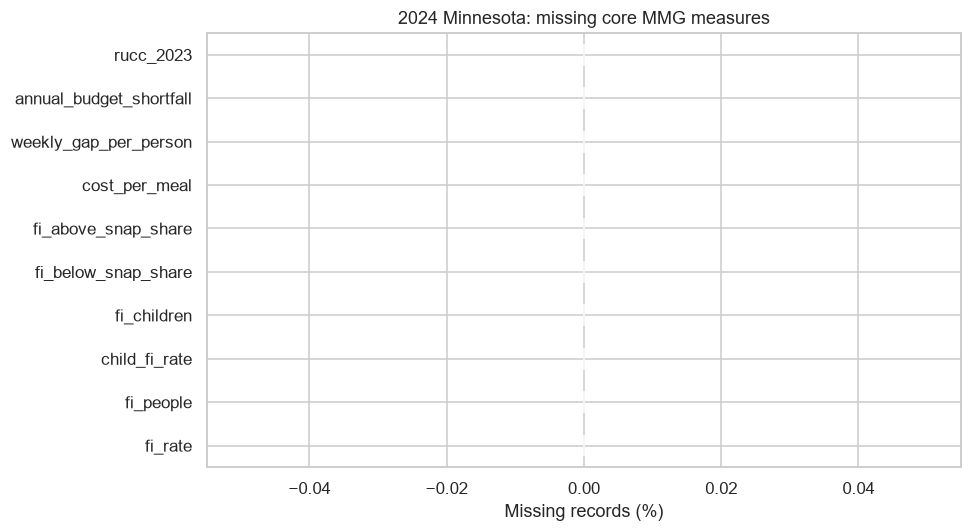

In [7]:
print('Exact duplicate rows:', mmg_mn.duplicated().sum())
print('Duplicate FIPS/year combinations:', mmg_mn.duplicated(['FIPS','Year']).sum())
print('Missing FIPS/year:', mmg_mn[['FIPS','Year']].isna().sum().to_dict())

core_fields = [
    'fi_rate', 'fi_people', 'child_fi_rate', 'fi_children',
    'fi_below_snap_share', 'fi_above_snap_share',
    'cost_per_meal', 'weekly_gap_per_person', 'annual_budget_shortfall',
    'rucc_2023'
]
missing_summary = pd.DataFrame({
    'missing_count': mmg_mn[core_fields].isna().sum(),
    'missing_pct': mmg_mn[core_fields].isna().mean() * 100
}).sort_values('missing_pct', ascending=False)
display(missing_summary.round(2))

plt.figure(figsize=(9, 5))
missing_summary['missing_pct'].sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Missing records (%)')
plt.title('2024 Minnesota: missing core MMG measures')
plt.tight_layout()
plt.show()

## Step 8 — Validate rate ranges and count relationships
Flag potential issues; do not erase modeled estimates or fill unpublished subgroup values with zero.

In [8]:
rate_cols = [
    'fi_rate', 'child_fi_rate', 'fi_below_snap_share',
    'fi_above_snap_share', 'child_fi_below_185fpl_share',
    'child_fi_above_185fpl_share',
    'fi_rate_black', 'fi_rate_hispanic', 'fi_rate_white_non_hispanic'
]
for col in rate_cols:
    values = mmg_mn[col].dropna()
    print(f'{col}: {(~values.between(0, 1)).sum()} values outside [0, 1]')

for col in ['fi_people','fi_children','cost_per_meal',
            'weekly_gap_per_person','annual_budget_shortfall']:
    print(f'{col}: {(mmg_mn[col].dropna() < 0).sum()} negative values')

snap_sum = mmg_mn['fi_below_snap_share'] + mmg_mn['fi_above_snap_share']
child_sum = mmg_mn['child_fi_below_185fpl_share'] + mmg_mn['child_fi_above_185fpl_share']
print('SNAP shares not within 1 ± 0.02:', ((snap_sum - 1).abs() > 0.02).sum())
print('Child income shares not within 1 ± 0.02:', ((child_sum - 1).abs() > 0.02).sum())
print('Child FI count > overall FI count:',
      (mmg_mn['fi_children'] > mmg_mn['fi_people']).sum())

# Two complementary shares need not add to exactly 1.000 due to rounding.

fi_rate: 0 values outside [0, 1]
child_fi_rate: 0 values outside [0, 1]
fi_below_snap_share: 0 values outside [0, 1]
fi_above_snap_share: 0 values outside [0, 1]
child_fi_below_185fpl_share: 0 values outside [0, 1]
child_fi_above_185fpl_share: 0 values outside [0, 1]
fi_rate_black: 0 values outside [0, 1]
fi_rate_hispanic: 0 values outside [0, 1]
fi_rate_white_non_hispanic: 0 values outside [0, 1]
fi_people: 0 negative values
fi_children: 0 negative values
cost_per_meal: 0 negative values
weekly_gap_per_person: 0 negative values
annual_budget_shortfall: 0 negative values
SNAP shares not within 1 ± 0.02: 0
Child income shares not within 1 ± 0.02: 0
Child FI count > overall FI count: 0


## Step 9 — 2024 overall food insecurity: descriptive statistics
Use **rates** to compare relative intensity of modeled need and **estimated people** to compare potential scale. The arithmetic mean of county rates is *not* the statewide rate.

,count,mean,std,min,25%,50%,75%,max
fi_rate,87.000,0.121,0.019,0.071,0.110,0.123,0.132,0.167
fi_people,87.000,"7,317.356","17,748.697",400.000,"1,415.000","2,830.000","5,240.000","143,160.000"
child_fi_rate,87.000,0.170,0.030,0.104,0.147,0.168,0.190,0.261
fi_children,87.000,"2,360.115","5,516.879",120.000,440.000,880.000,"1,795.000","41,950.000"
cost_per_meal,87.000,3.831,0.295,3.280,3.650,3.790,3.940,5.080


Unweighted average county rate: 12.08 %
Median county rate: 12.3 %
Sum of county-level FI people estimates: 636610


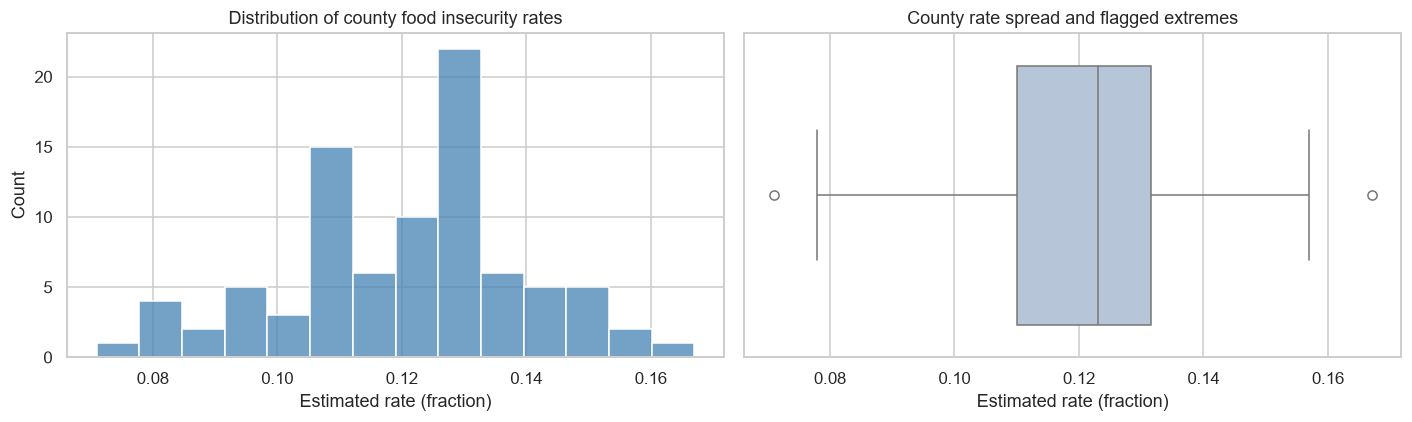

In [9]:
display(mmg_mn[['fi_rate','fi_people','child_fi_rate',
                'fi_children','cost_per_meal']].describe().T)

print('Unweighted average county rate:', round(mmg_mn['fi_rate'].mean()*100, 2), '%')
print('Median county rate:', round(mmg_mn['fi_rate'].median()*100, 2), '%')
print('Sum of county-level FI people estimates:', int(mmg_mn['fi_people'].sum()))
print('WARNING: this county sum may differ from the State worksheet estimate.')

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=mmg_mn, x='fi_rate', bins=14, ax=axs[0], color='steelblue')
axs[0].set_title('Distribution of county food insecurity rates')
axs[0].set_xlabel('Estimated rate (fraction)')
sns.boxplot(data=mmg_mn, x='fi_rate', ax=axs[1], color='lightsteelblue')
axs[1].set_title('County rate spread and flagged extremes')
axs[1].set_xlabel('Estimated rate (fraction)')
plt.tight_layout()
plt.show()

## Step 10 — Rank counties by estimated food insecurity rate
High-rate counties should not be assumed to contain the greatest absolute number of food-insecure residents.

Highest rates:


,county_name,FIPS,fi_rate,fi_people
1359,Mahnomen,27087,0.167,900.000
1391,Swift,27151,0.157,"1,530.000"
1361,Martin,27091,0.154,"3,040.000"
1368,Nobles,27105,0.152,"3,340.000"
1330,Clearwater,27029,0.151,"1,300.000"
1316,Aitkin,27001,0.150,"2,420.000"
1319,Beltrami,27007,0.150,"7,000.000"
1398,Watonwan,27165,0.149,"1,670.000"
1327,Chippewa,27023,0.146,"1,810.000"
1351,Koochiching,27071,0.143,"1,690.000"


Lowest rates:


,county_name,FIPS,fi_rate,fi_people
1385,Scott,27139,0.071,"11,040.000"
1325,Carver,27019,0.078,"8,570.000"
1401,Wright,27171,0.079,"11,730.000"
1397,Washington,27163,0.081,"22,480.000"
1386,Sherburne,27141,0.083,"8,370.000"
1317,Anoka,27003,0.089,"32,940.000"
1328,Chisago,27025,0.090,"5,230.000"
1343,Houston,27055,0.092,"1,720.000"
1335,Dodge,27039,0.093,"1,960.000"
1334,Dakota,27037,0.094,"41,960.000"


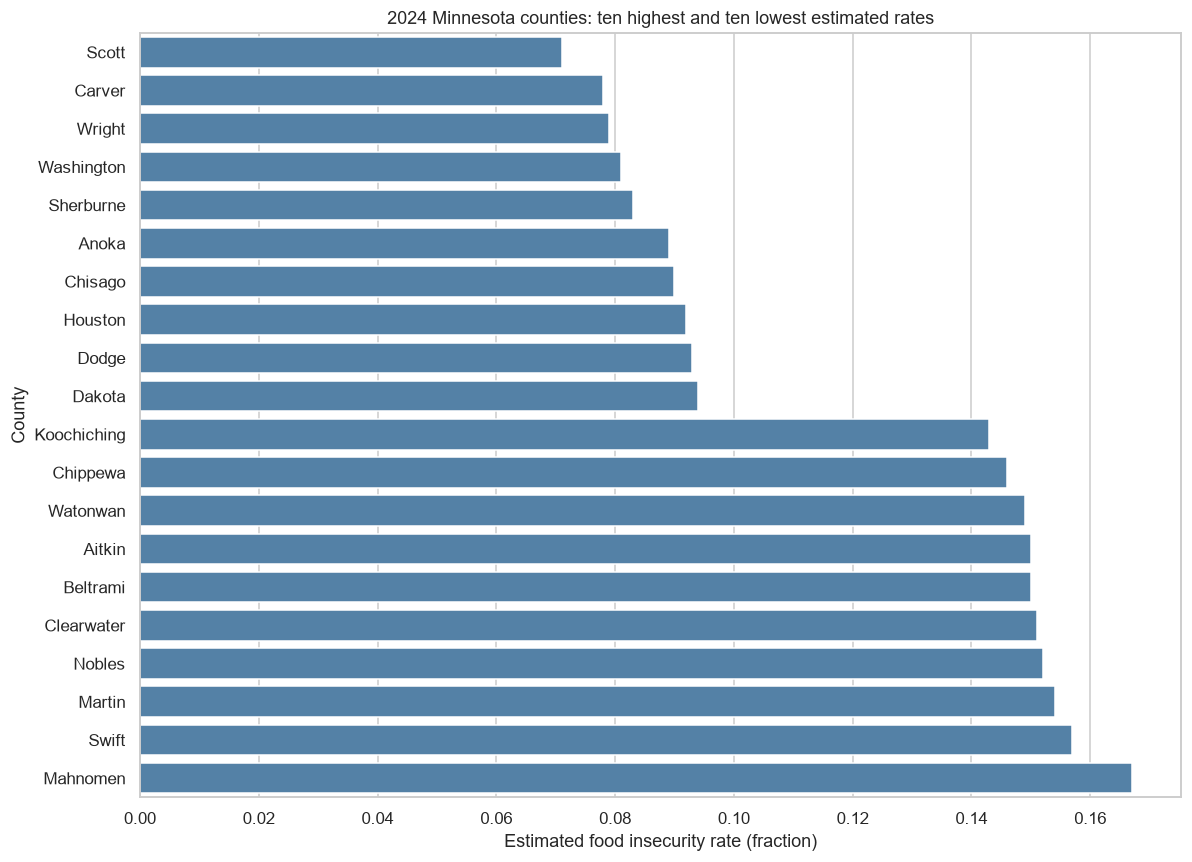

In [10]:
highest_rate = mmg_mn.nlargest(10,'fi_rate')[['county_name','FIPS','fi_rate','fi_people']]
lowest_rate = mmg_mn.nsmallest(10,'fi_rate')[['county_name','FIPS','fi_rate','fi_people']]
print('Highest rates:')
display(highest_rate)
print('Lowest rates:')
display(lowest_rate)

rank_plot = pd.concat([mmg_mn.nlargest(10,'fi_rate'),
                       mmg_mn.nsmallest(10,'fi_rate')]).drop_duplicates('FIPS')
rank_plot = rank_plot.sort_values('fi_rate')
plt.figure(figsize=(11, 8))
sns.barplot(data=rank_plot, x='fi_rate', y='county_name', color='steelblue')
plt.title('2024 Minnesota counties: ten highest and ten lowest estimated rates')
plt.xlabel('Estimated food insecurity rate (fraction)')
plt.ylabel('County')
plt.tight_layout()
plt.show()

## Step 11 — Compare rate and estimated number of people
This distinction affects how food shelf resource allocation might differ when based on need counts versus need rates.

Counties with the most food-insecure people:


,county_name,FIPS,fi_people,fi_rate
1342,Hennepin,27053,"143,160.000",0.113
1377,Ramsey,27123,"71,270.000",0.131
1334,Dakota,27037,"41,960.000",0.094
1317,Anoka,27003,"32,940.000",0.089
1384,St. Louis,27137,"27,590.000",0.138
1397,Washington,27163,"22,480.000",0.081
1388,Stearns,27145,"19,670.000",0.122
1370,Olmsted,27109,"16,490.000",0.100
1401,Wright,27171,"11,730.000",0.079
1385,Scott,27139,"11,040.000",0.071


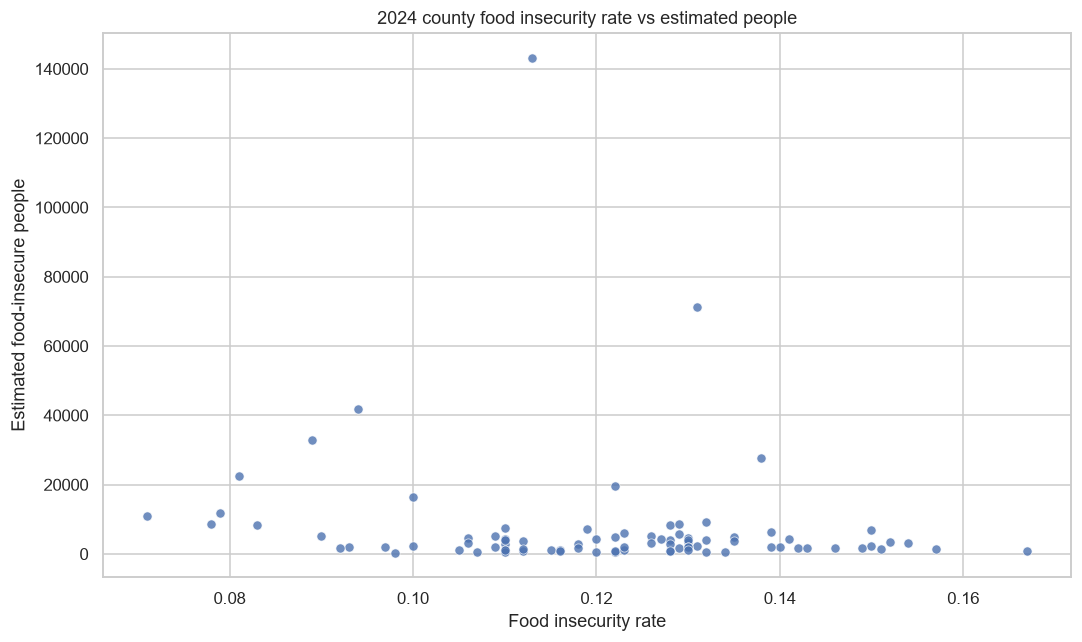

In [11]:
print('Counties with the most food-insecure people:')
display(mmg_mn.nlargest(10,'fi_people')[['county_name','FIPS','fi_people','fi_rate']])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=mmg_mn, x='fi_rate', y='fi_people', alpha=0.8)
plt.title('2024 county food insecurity rate vs estimated people')
plt.xlabel('Food insecurity rate')
plt.ylabel('Estimated food-insecure people')
plt.tight_layout()
plt.show()

## Step 12 — Child food insecurity
Examine child rates and child counts independently of overall estimates. The rates refer to different denominators.

Child minus overall rate, in percentage points:


count   87.000
mean     4.917
std      1.486
min      2.500
25%      3.850
50%      4.800
75%      5.800
max     10.200
Name: child_minus_overall_pp, dtype: float64

Ten largest child–overall rate gaps:


,county_name,child_fi_rate,fi_rate,child_minus_overall_pp,fi_children
1331,Cook,0.222,0.120,10.200,180.000
1359,Mahnomen,0.261,0.167,9.400,430.000
1327,Chippewa,0.225,0.146,7.900,680.000
1354,Lake of the Woods,0.185,0.107,7.800,130.000
1341,Grant,0.203,0.128,7.500,290.000
1316,Aitkin,0.220,0.150,7.000,550.000
1377,Ramsey,0.200,0.131,6.900,"25,060.000"
1353,Lake,0.185,0.116,6.900,380.000
1361,Martin,0.222,0.154,6.800,"1,000.000"
1326,Cass,0.199,0.132,6.700,"1,230.000"


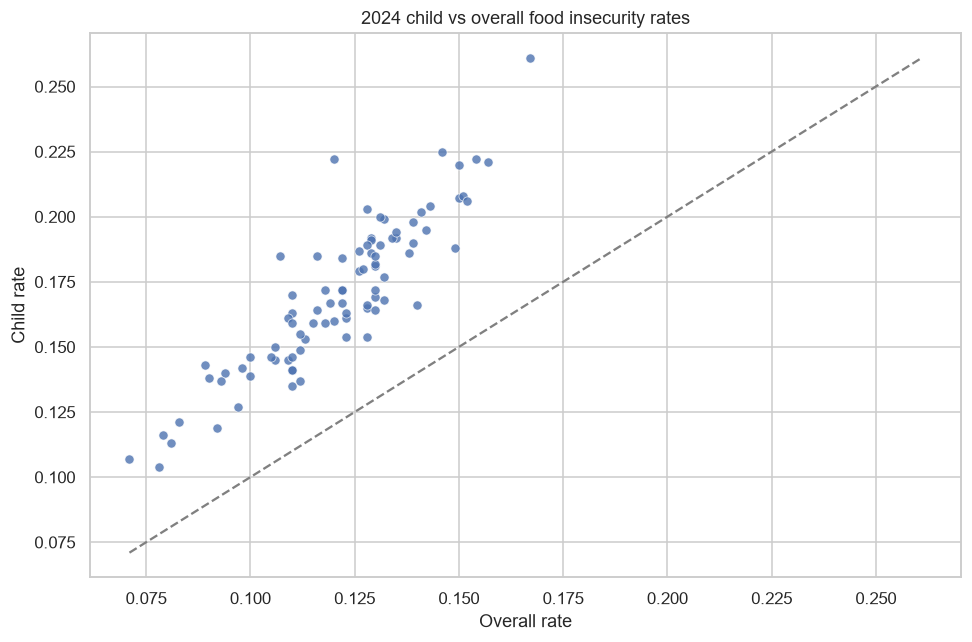

In [12]:
mmg_mn['child_minus_overall_pp'] = (
    mmg_mn['child_fi_rate'] - mmg_mn['fi_rate']
) * 100

print('Child minus overall rate, in percentage points:')
display(mmg_mn['child_minus_overall_pp'].describe())
print('Ten largest child–overall rate gaps:')
display(mmg_mn.nlargest(10,'child_minus_overall_pp')[
    ['county_name','child_fi_rate','fi_rate','child_minus_overall_pp','fi_children']
])

plt.figure(figsize=(9, 6))
sns.scatterplot(data=mmg_mn, x='fi_rate', y='child_fi_rate', alpha=0.8)
low = min(mmg_mn['fi_rate'].min(), mmg_mn['child_fi_rate'].min())
high = max(mmg_mn['fi_rate'].max(), mmg_mn['child_fi_rate'].max())
plt.plot([low, high], [low, high], linestyle='--', color='gray')
plt.title('2024 child vs overall food insecurity rates')
plt.xlabel('Overall rate')
plt.ylabel('Child rate')
plt.tight_layout()
plt.show()

## Step 13 — Food-insecure children by household income relative to 185% FPL
These modeled shares relate to a child-nutrition income threshold. They are **not** school lunch enrollment or counts of children using meal programs.

,count,mean,std,min,25%,50%,75%,max
child_fi_below_185fpl_share,87.000,0.679,0.141,0.230,0.570,0.690,0.775,0.980
child_fi_above_185fpl_share,87.000,0.322,0.141,0.030,0.225,0.310,0.430,0.770


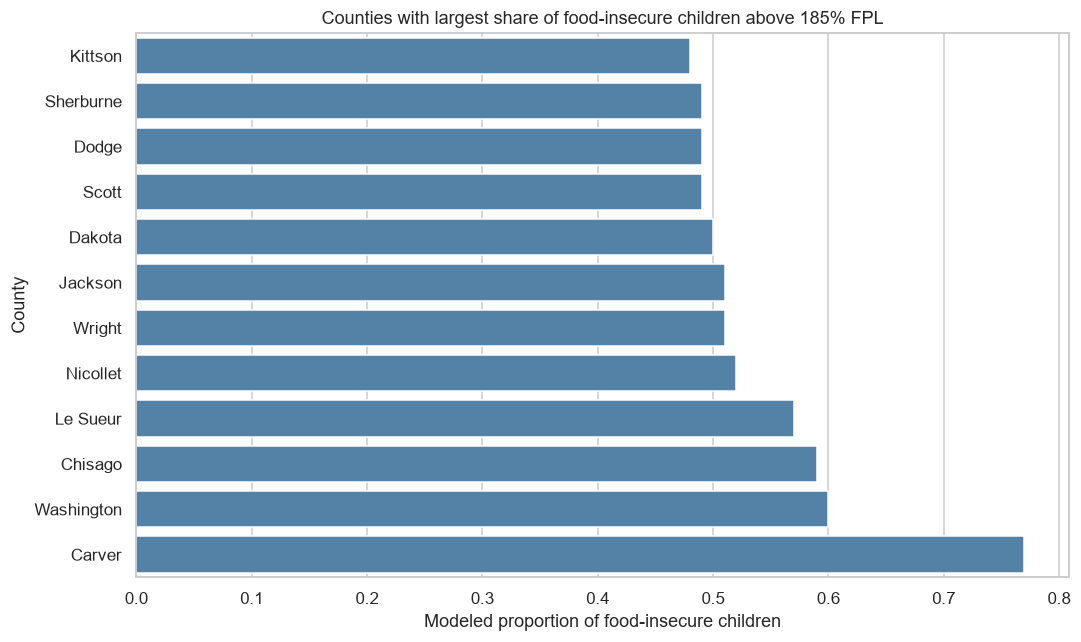

In [13]:
child_income_cols = [
    'child_fi_below_185fpl_share', 'child_fi_above_185fpl_share'
]
display(mmg_mn[child_income_cols].describe().T)

plot_child = mmg_mn.nlargest(12, 'child_fi_above_185fpl_share').sort_values('child_fi_above_185fpl_share')
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_child, x='child_fi_above_185fpl_share', y='county_name', color='steelblue')
plt.title('Counties with largest share of food-insecure children above 185% FPL')
plt.xlabel('Modeled proportion of food-insecure children')
plt.ylabel('County')
plt.tight_layout()
plt.show()

## Step 14 — SNAP income threshold and food insecurity
`SNAP Threshold` is the state gross-income cutoff expressed relative to federal poverty guidelines. It is **not** SNAP enrollment, applications, benefit amounts, or approval rates.

,count,mean,std,min,25%,50%,75%,max
snap_threshold,87.000,2.000,0.000,2.000,2.000,2.000,2.000,2.000
fi_below_snap_share,87.000,0.645,0.096,0.346,0.585,0.653,0.712,0.863
fi_above_snap_share,87.000,0.355,0.096,0.137,0.287,0.347,0.415,0.654


Unique SNAP income thresholds across Minnesota counties: [2.]


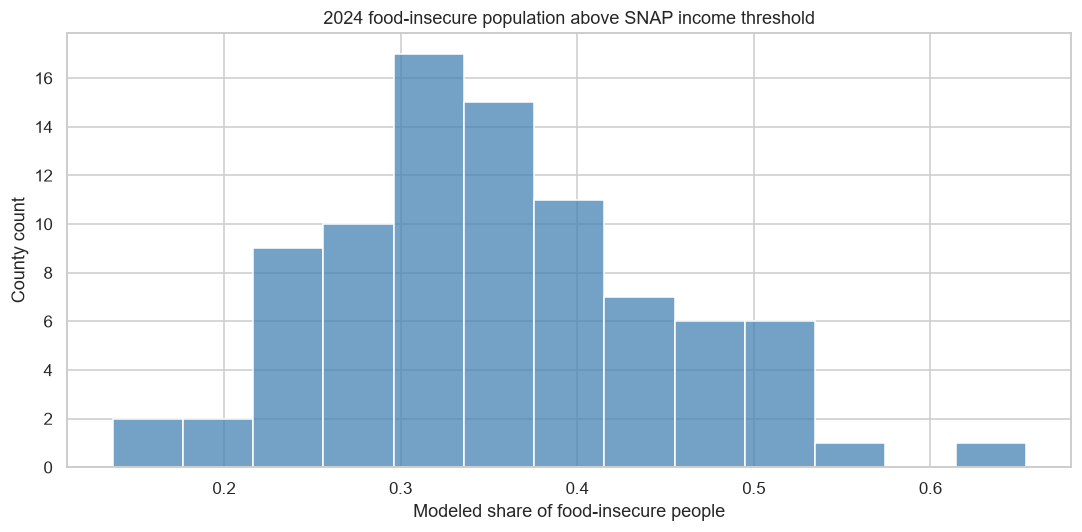

Highest shares above SNAP threshold:


,county_name,fi_above_snap_share,fi_rate,fi_people
1325,Carver,0.654,0.078,"8,570.000"
1397,Washington,0.564,0.081,"22,480.000"
1334,Dakota,0.526,0.094,"41,960.000"
1401,Wright,0.524,0.079,"11,730.000"
1328,Chisago,0.521,0.090,"5,230.000"
1385,Scott,0.520,0.071,"11,040.000"
1370,Olmsted,0.504,0.100,"16,490.000"
1386,Sherburne,0.498,0.083,"8,370.000"
1355,Le Sueur,0.486,0.106,"3,100.000"
1394,Wabasha,0.483,0.097,"2,080.000"


In [14]:
snap_cols = ['snap_threshold','fi_below_snap_share','fi_above_snap_share']
display(mmg_mn[snap_cols].describe().T)
print('Unique SNAP income thresholds across Minnesota counties:',
      mmg_mn['snap_threshold'].dropna().unique())

plt.figure(figsize=(10, 5))
sns.histplot(data=mmg_mn, x='fi_above_snap_share', bins=13, color='steelblue')
plt.title('2024 food-insecure population above SNAP income threshold')
plt.xlabel('Modeled share of food-insecure people')
plt.ylabel('County count')
plt.tight_layout()
plt.show()

print('Highest shares above SNAP threshold:')
display(mmg_mn.nlargest(10, 'fi_above_snap_share')[
    ['county_name','fi_above_snap_share','fi_rate','fi_people']
])

## Step 15 — Market basket price imputation: frequency and locations
**2024-only field.** A labeled `imputed` cell means localized market basket data were imputed. The source warns that imputation can understate local costs if nearby counties have lower food prices.

,imputed,counties
0,False,48
1,True,39


Counties flagged imputed: 39


,county_name,FIPS,cost_per_meal,rucc_2023
1316,Aitkin,27001,3.860,8
1321,Big Stone,27011,3.600,9
1327,Chippewa,27023,3.720,7
1330,Clearwater,27029,3.590,8
1331,Cook,27031,3.800,9
1332,Cottonwood,27033,3.280,9
1337,Faribault,27043,3.670,8
1341,Grant,27051,3.850,9
1343,Houston,27055,4.060,3
1347,Jackson,27063,3.280,9


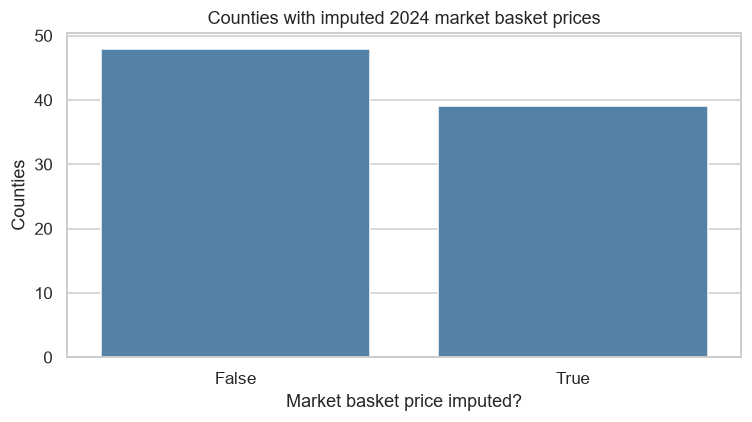

In [15]:
imputation_counts = (
    mmg_mn['market_basket_imputed']
    .value_counts(dropna=False)
    .rename_axis('imputed')
    .reset_index(name='counties')
)
display(imputation_counts)
print('Counties flagged imputed:', int(mmg_mn['market_basket_imputed'].sum()))

display(mmg_mn.loc[mmg_mn['market_basket_imputed'],
                   ['county_name','FIPS','cost_per_meal','rucc_2023']]
        .sort_values('county_name'))

plt.figure(figsize=(7, 4))
sns.countplot(data=mmg_mn, x='market_basket_imputed', color='steelblue')
plt.title('Counties with imputed 2024 market basket prices')
plt.xlabel('Market basket price imputed?')
plt.ylabel('Counties')
plt.tight_layout()
plt.show()

## Step 16 — Estimated cost per meal; compare imputed vs unflagged
Within-year differences may reflect real local cost differences, geographic context, and/or imputation. This is not a test of inflation and is not a causal comparison.

2024 estimated cost per meal — overall:


count   87.000
mean     3.831
std      0.295
min      3.280
25%      3.650
50%      3.790
75%      3.940
max      5.080
Name: cost_per_meal, dtype: float64

By imputation flag:


,count,mean,std,min,25%,50%,75%,max
market_basket_imputed,,,,,,,,
False,48.000,3.940,0.330,3.280,3.670,3.875,4.172,5.080
True,39.000,3.697,0.168,3.280,3.600,3.680,3.825,4.060


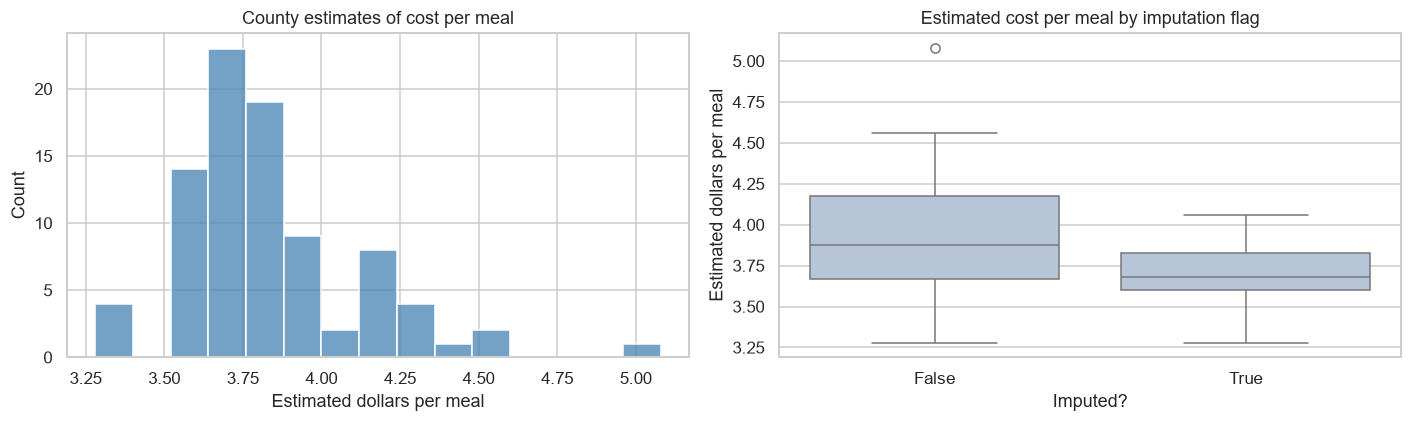

Highest cost-per-meal counties:


,county_name,cost_per_meal,market_basket_imputed,fi_rate
1328,Chisago,5.080,False,0.090
1342,Hennepin,4.560,False,0.113
1325,Carver,4.500,False,0.078
1355,Le Sueur,4.400,False,0.106
1338,Fillmore,4.340,False,0.100
1377,Ramsey,4.330,False,0.131
1367,Nicollet,4.280,False,0.112
1320,Benton,4.250,False,0.126
1335,Dodge,4.200,False,0.093
1385,Scott,4.200,False,0.071


In [16]:
print('2024 estimated cost per meal — overall:')
display(mmg_mn['cost_per_meal'].describe())
print('By imputation flag:')
display(mmg_mn.groupby('market_basket_imputed')['cost_per_meal'].describe())

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=mmg_mn, x='cost_per_meal', bins=15, ax=axs[0], color='steelblue')
axs[0].set_title('County estimates of cost per meal')
axs[0].set_xlabel('Estimated dollars per meal')
sns.boxplot(data=mmg_mn, x='market_basket_imputed', y='cost_per_meal',
            ax=axs[1], color='lightsteelblue')
axs[1].set_title('Estimated cost per meal by imputation flag')
axs[1].set_xlabel('Imputed?')
axs[1].set_ylabel('Estimated dollars per meal')
plt.tight_layout()
plt.show()

print('Highest cost-per-meal counties:')
display(mmg_mn.nlargest(10,'cost_per_meal')[
    ['county_name','cost_per_meal','market_basket_imputed','fi_rate']
])

## Step 17 — Annual food budget shortfalls
This amount is a modeled shortfall. Larger counties may have larger aggregate shortfalls because they contain more residents. Do not compare with estimates **before 2023** as though methodology were unchanged.

,count,mean,std,min,25%,50%,75%,max
weekly_gap_per_person,87.000,23.978,1.844,20.550,22.850,23.720,24.680,31.780
annual_budget_shortfall,87.000,"5,715,620.690","15,069,464.767","279,000.000","976,000.000","2,021,000.000","4,125,000.000","124,020,000.000"


Largest estimated annual budget shortfalls:


,county_name,annual_budget_shortfall,fi_people,cost_per_meal,market_basket_imputed
1342,Hennepin,"124,020,000.000","143,160.000",4.560,False
1377,Ramsey,"58,611,000.000","71,270.000",4.330,False
1334,Dakota,"32,882,000.000","41,960.000",4.130,False
1317,Anoka,"24,662,000.000","32,940.000",3.940,False
1384,St. Louis,"20,119,000.000","27,590.000",3.840,False
1397,Washington,"17,807,000.000","22,480.000",4.170,False
1388,Stearns,"13,879,000.000","19,670.000",3.720,False
1370,Olmsted,"12,310,000.000","16,490.000",3.930,False
1401,Wright,"9,325,000.000","11,730.000",4.190,False
1385,Scott,"8,801,000.000","11,040.000",4.200,False


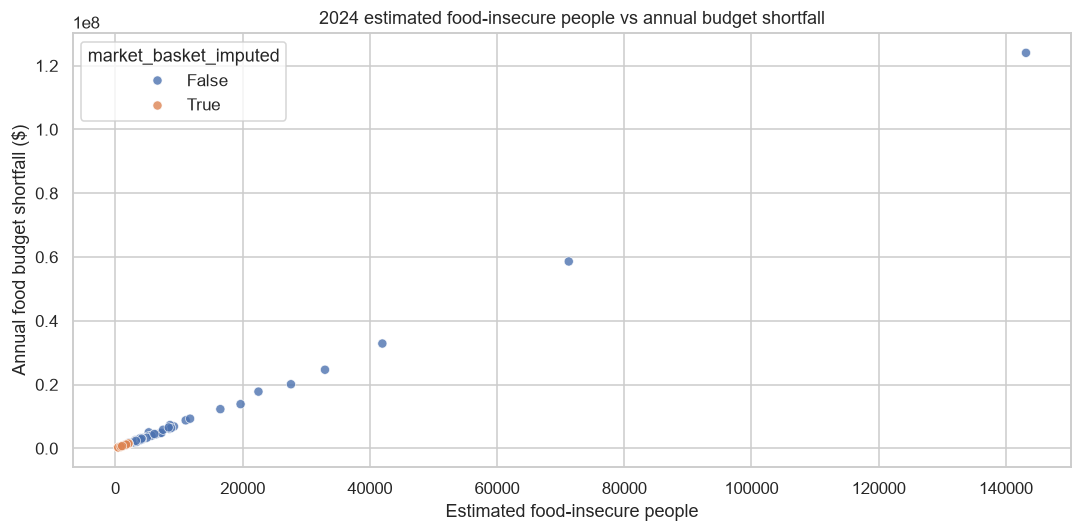

In [17]:
display(mmg_mn[['weekly_gap_per_person','annual_budget_shortfall']].describe().T)
print('Largest estimated annual budget shortfalls:')
display(mmg_mn.nlargest(10, 'annual_budget_shortfall')[
    ['county_name','annual_budget_shortfall','fi_people','cost_per_meal','market_basket_imputed']
])

plt.figure(figsize=(10, 5))
sns.scatterplot(data=mmg_mn, x='fi_people', y='annual_budget_shortfall',
                hue='market_basket_imputed', alpha=0.8)
plt.title('2024 estimated food-insecure people vs annual budget shortfall')
plt.xlabel('Estimated food-insecure people')
plt.ylabel('Annual food budget shortfall ($)')
plt.tight_layout()
plt.show()

## Step 18 — Metro versus nonmetro county food insecurity
Use the supplied **2023** USDA Rural-Urban Continuum Code: 1–3 metropolitan, 4–9 nonmetropolitan. RUCC is a county classification, not a measure of travel time or food shelf accessibility.

Counties by metro classification:


metro_status
Nonmetro (4–9)    60
Metro (1–3)       27
Name: count, dtype: Int64

FI rates by metro classification:


,count,mean,std,min,25%,50%,75%,max
metro_status,,,,,,,,
Metro (1–3),27.000,0.106,0.020,0.071,0.091,0.105,0.127,0.138
Nonmetro (4–9),60.000,0.128,0.015,0.098,0.116,0.128,0.136,0.167


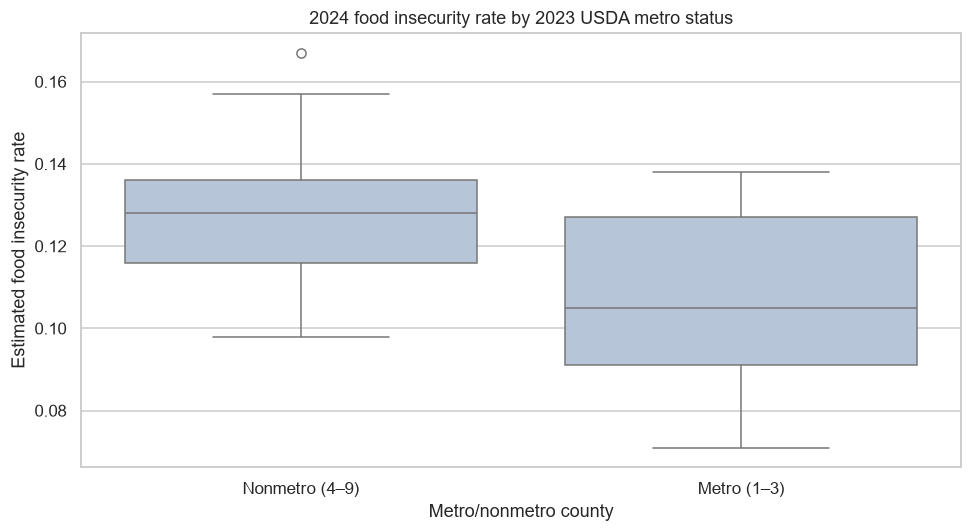

In [18]:
mmg_mn['rucc_2023'] = mmg_mn['rucc_2023'].astype('Int64')
mmg_mn['rucc_2013'] = mmg_mn['rucc_2013'].astype('Int64')
mmg_mn['metro_status'] = pd.Series(pd.NA, index=mmg_mn.index, dtype='string')
mmg_mn.loc[mmg_mn['rucc_2023'].between(1,3), 'metro_status'] = 'Metro (1–3)'
mmg_mn.loc[mmg_mn['rucc_2023'].between(4,9), 'metro_status'] = 'Nonmetro (4–9)'

print('Counties by metro classification:')
display(mmg_mn['metro_status'].value_counts(dropna=False))
print('FI rates by metro classification:')
display(mmg_mn.groupby('metro_status')['fi_rate'].describe())

plt.figure(figsize=(9, 5))
sns.boxplot(data=mmg_mn, x='metro_status', y='fi_rate', color='lightsteelblue')
plt.title('2024 food insecurity rate by 2023 USDA metro status')
plt.xlabel('Metro/nonmetro county')
plt.ylabel('Estimated food insecurity rate')
plt.tight_layout()
plt.show()

## Step 19 — Compare 2013 and 2023 RUCC classifications
This workbook includes both code vintages. A changed RUCC classification is **not** itself proof that food shelf access or food insecurity changed.

In [19]:
rucc_comparison = pd.crosstab(mmg_mn['rucc_2013'], mmg_mn['rucc_2023'])
display(rucc_comparison)

rucc_changed = mmg_mn.loc[
    mmg_mn['rucc_2013'].notna() & mmg_mn['rucc_2023'].notna()
    & mmg_mn['rucc_2013'].ne(mmg_mn['rucc_2023']),
    ['county_name','FIPS','rucc_2013','rucc_2023']
].sort_values('county_name')
print('Counties with a different RUCC code:', len(rucc_changed))
display(rucc_changed)

rucc_2023,1,2,3,4,5,6,7,8,9
rucc_2013,,,,,,,,,
1,13,0,0,0,0,0,0,1,0
2,0,2,0,0,0,0,0,0,0
3,0,0,11,0,0,0,0,0,0
4,0,0,0,5,0,1,0,0,0
5,0,0,0,0,1,0,0,0,0
6,0,1,0,1,0,9,1,8,0
7,0,0,0,0,0,1,6,0,7
8,0,0,0,0,0,0,0,7,1
9,0,0,0,0,0,0,0,0,11


Counties with a different RUCC code: 22


,county_name,FIPS,rucc_2013,rucc_2023
1332,Cottonwood,27033,7,9
1337,Faribault,27043,6,8
1340,Goodhue,27049,4,6
1344,Hubbard,27057,7,9
1347,Jackson,27063,7,9
1348,Kanabec,27065,6,8
1351,Koochiching,27071,6,7
1353,Lake,27075,6,8
1361,Martin,27091,7,6
1358,McLeod,27085,6,4


## Step 20 — Subgroup estimate availability
Rates for Black, Hispanic, and White non-Hispanic populations are suppressed/unavailable for some counties. These are **not zeros** and should never be used to generate counts by multiplying by county totals.

,population_group,available_counties,missing_counties,available_pct
0,Black persons (all ethnicities),24,63,27.586
1,Hispanic persons (any race),58,29,66.667
2,"White, non-Hispanic persons",87,0,100.000


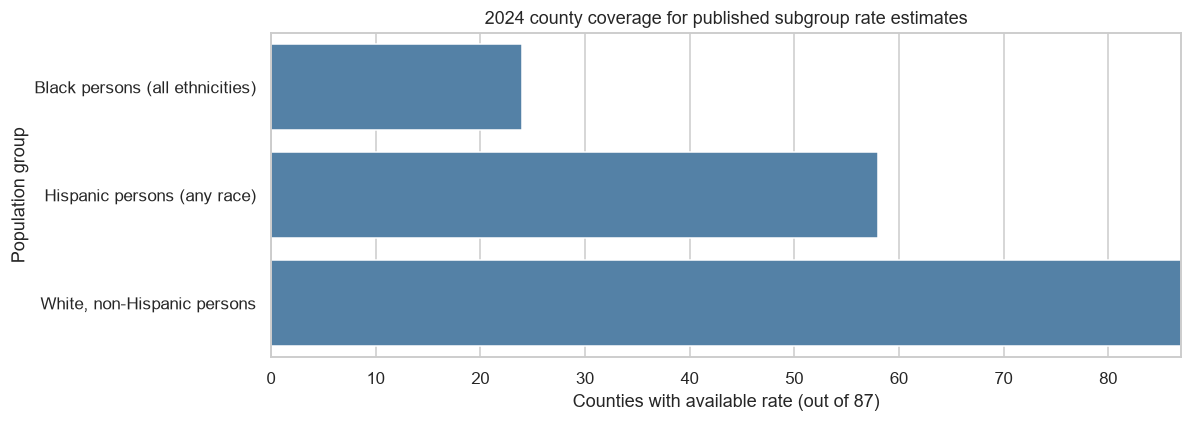

In [20]:
subgroups = {
    'fi_rate_black': 'Black persons (all ethnicities)',
    'fi_rate_hispanic': 'Hispanic persons (any race)',
    'fi_rate_white_non_hispanic': 'White, non-Hispanic persons'
}
subgroup_coverage = pd.DataFrame({
    'population_group': list(subgroups.values()),
    'available_counties': [mmg_mn[c].notna().sum() for c in subgroups],
    'missing_counties': [mmg_mn[c].isna().sum() for c in subgroups]
})
subgroup_coverage['available_pct'] = subgroup_coverage['available_counties'] / len(mmg_mn) * 100
display(subgroup_coverage)

plt.figure(figsize=(11, 4))
sns.barplot(data=subgroup_coverage, x='available_counties', y='population_group', color='steelblue')
plt.title('2024 county coverage for published subgroup rate estimates')
plt.xlabel('Counties with available rate (out of 87)')
plt.ylabel('Population group')
plt.xlim(0, 87)
plt.tight_layout()
plt.show()

## Step 21 — Correlations among 2024 modeled indicators
This is an exploratory screen for redundancy and associations, **not** evidence of causality. Several variables originate from the same modeling framework and share components.

,fi_rate,fi_people,child_fi_rate,fi_children,fi_above_snap_share,cost_per_meal,weekly_gap_per_person,annual_budget_shortfall
fi_rate,1.000,-0.140,0.880,-0.140,-0.700,-0.440,-0.440,-0.170
fi_people,-0.140,1.000,-0.180,0.990,0.320,0.440,0.440,1.000
child_fi_rate,0.880,-0.180,1.000,-0.160,-0.710,-0.410,-0.410,-0.210
fi_children,-0.140,0.990,-0.160,1.000,0.310,0.420,0.420,0.990
fi_above_snap_share,-0.700,0.320,-0.710,0.310,1.000,0.440,0.440,0.340
cost_per_meal,-0.440,0.440,-0.410,0.420,0.440,1.000,1.000,0.490
weekly_gap_per_person,-0.440,0.440,-0.410,0.420,0.440,1.000,1.000,0.490
annual_budget_shortfall,-0.170,1.000,-0.210,0.990,0.340,0.490,0.490,1.000


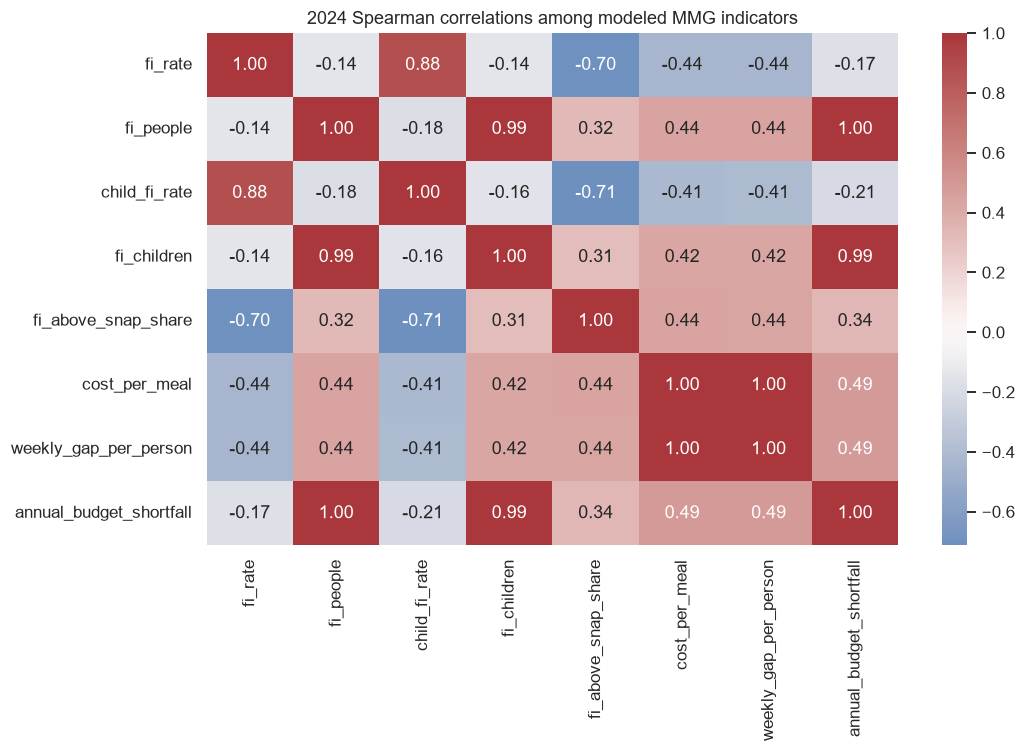

In [21]:
corr_fields = [
    'fi_rate','fi_people','child_fi_rate','fi_children',
    'fi_above_snap_share','cost_per_meal', 'weekly_gap_per_person',
    'annual_budget_shortfall'
]
spearman_corr = mmg_mn[corr_fields].corr(method='spearman')
display(spearman_corr.round(2))

plt.figure(figsize=(10, 7))
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('2024 Spearman correlations among modeled MMG indicators')
plt.tight_layout()
plt.show()

## Step 22 — Flag outlying county rates for review
IQR is a simple exploratory rule. Extreme counties should **not** automatically be dropped; they may be substantively important.

In [22]:
q1, q3 = mmg_mn['fi_rate'].quantile([0.25,0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outlier_review = mmg_mn.loc[
    (mmg_mn['fi_rate'] < lower) | (mmg_mn['fi_rate'] > upper),
    ['FIPS','county_name','Year','fi_rate','fi_people']
].sort_values('fi_rate', ascending=False)
print('IQR lower/upper bounds:', round(lower,4), round(upper,4))
print('Flagged counties:', len(outlier_review))
display(outlier_review)

IQR lower/upper bounds: 0.0777 0.1638
Flagged counties: 2


,FIPS,county_name,Year,fi_rate,fi_people
1359,27087,Mahnomen,2024,0.167,900.000
1385,27139,Scott,2024,0.071,"11,040.000"


## Step 23 — Optional 2023 ↔ 2024 core FI comparison
This optional step reads the already reviewed **corrected v2 MMG2025** workbook, if present, to check county continuity. Only compare **core modeled rates/counts** here, and interpret small differences cautiously. Do **not** calculate meal-cost inflation between 2022 and 2023 because of the 2023 methodology change. Do not treat 2023-to-2024 FI differences as statistically proven changes.

In [23]:
mmg2025_path = Path('data/MMG2025_2019-2023_Data_To_Share_v2.xlsx')
comparison_2023_2024 = pd.DataFrame()

if mmg2025_path.is_file():
    prev = pd.read_excel(
        mmg2025_path, sheet_name='County',
        dtype={'FIPS': 'string'}, engine='openpyxl',
        usecols=['FIPS','State','Year',
                 'Overall Food Insecurity Rate',
                 '# of Food Insecure Persons Overall']
    )
    prev = prev.loc[
        prev['State'].astype('string').str.strip().eq('MN')
        & pd.to_numeric(prev['Year'], errors='coerce').eq(2023)
    ].copy()
    prev['FIPS'] = prev['FIPS'].astype('string').str.zfill(5)
    prev = prev.rename(columns={
        'Overall Food Insecurity Rate': 'fi_rate_2023',
        '# of Food Insecure Persons Overall': 'fi_people_2023'
    })
    comparison_2023_2024 = mmg_mn[
        ['FIPS','county_name','fi_rate','fi_people']
    ].merge(
        prev[['FIPS','fi_rate_2023','fi_people_2023']],
        on='FIPS', how='left', validate='one_to_one'
    )
    comparison_2023_2024['rate_change_pp'] = 100 * (
        comparison_2023_2024['fi_rate'] - comparison_2023_2024['fi_rate_2023']
    )
    print('2023–2024 joined Minnesota counties:',len(comparison_2023_2024))
    print('Missing 2023 values:',comparison_2023_2024['fi_rate_2023'].isna().sum())
    display(comparison_2023_2024.nlargest(10,'rate_change_pp'))
else:
    print('Optional comparison skipped (MMG2025 workbook is not in data/).')

# The required stand-alone 2024 EDA works without the 2025 workbook.

2023–2024 joined Minnesota counties: 87
Missing 2023 values: 0


,FIPS,county_name,fi_rate,fi_people,fi_rate_2023,fi_people_2023,rate_change_pp
75,27151,Swift,0.157,"1,530.000",0.125,"1,220.000",3.200
82,27165,Watonwan,0.149,"1,670.000",0.117,"1,310.000",3.200
52,27105,Nobles,0.152,"3,340.000",0.121,"2,660.000",3.100
45,27091,Martin,0.154,"3,040.000",0.125,"2,490.000",2.900
74,27149,Stevens,0.130,"1,270.000",0.108,"1,050.000",2.200
56,27113,Pennington,0.140,"1,930.000",0.119,"1,650.000",2.100
2,27005,Becker,0.135,"4,760.000",0.117,"4,120.000",1.800
23,27047,Freeborn,0.128,"3,910.000",0.110,"3,370.000",1.800
33,27067,Kandiyohi,0.129,"5,680.000",0.113,"4,930.000",1.600
46,27093,Meeker,0.118,"2,770.000",0.102,"2,380.000",1.600


## Step 24 — Export prepared tables and review outputs
Exports are written relative to the notebook in the project root. Treat the original workbook and row-level extracts according to the data provider’s sharing permissions.

In [24]:
OUTPUT_DIR = Path('outputs/mmg2026_eda')
FIGURE_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

mmg_mn.to_csv(OUTPUT_DIR / 'mmg_minnesota_2024.csv', index=False)
missing_summary.to_csv(OUTPUT_DIR / 'mmg_2024_missing_core_fields.csv')
subgroup_coverage.to_csv(OUTPUT_DIR / 'mmg_2024_subgroup_coverage.csv', index=False)
rucc_changed.to_csv(OUTPUT_DIR / 'mmg_2024_rucc_changes.csv', index=False)
outlier_review.to_csv(OUTPUT_DIR / 'mmg_2024_outlier_review.csv', index=False)
imputation_counts.to_csv(OUTPUT_DIR / 'mmg_2024_market_basket_imputation_counts.csv', index=False)
mmg_mn[['FIPS','county_name','fi_rate','fi_people','child_fi_rate',
        'fi_children','cost_per_meal','market_basket_imputed']].to_csv(
    OUTPUT_DIR / 'mmg_2024_core_summary.csv', index=False
)
if not comparison_2023_2024.empty:
    comparison_2023_2024.to_csv(
        OUTPUT_DIR / 'mmg_2023_2024_optional_comparison.csv', index=False
    )

print('Saved 2024 analysis outputs to:', OUTPUT_DIR.resolve())
print('To save any figure, put plt.savefig(FIGURE_DIR / "name.png", dpi=300, bbox_inches="tight") before plt.show().')

Saved 2024 analysis outputs to: C:\Users\vasquema\Documents\GitHub\minnemudac-insight-team\outputs\mmg2026_eda
To save any figure, put plt.savefig(FIGURE_DIR / "name.png", dpi=300, bbox_inches="tight") before plt.show().
